# Case Study 148: Network Intrusion Detection Using Machine Learning

**Anshuman Atrey** · Roll No. 150096724029 · B.Tech CSE 2024-28, Semester V · Machine Learning Fundamentals (Major Project)

| | |
|---|------------------|
| **case study** | 148, network intrusion detection: analyse traffic, find what malicious traffic looks like, compare 6 algorithms, build a prototype IDS |
| **dataset** | [CICIoT2023](https://www.unb.ca/cic/datasets/iotdataset-2023.html) (Canadian Institute for Cybersecurity, 2023): 46.7 million flows from a real network of 105 IoT devices, 33 attacks in 7 families plus benign traffic. on kaggle as [UNB CIC IOT 2023](https://www.kaggle.com/datasets/madhavmalhotra/unb-cic-iot-dataset) (the original 169 CSV parts) |
| **why this dataset** | its recent (captured 2023, not the 1999 KDD traffic most courses use), its from real devices, and it has every attack family a modern network sees: floods, botnets, scans, spoofing, web attacks, password guessing. it fits [Walrus Securitas](https://walrussecuritas.com/), the security company im building |
| **models** | every classifier taught in the course, 11 in all: logistic regression, KNN, decision tree (module V), K-Means as an unsupervised detector (module VII), random forest, bagging, AdaBoost, gradient boosting (module VIII), perceptron, neural network (module IX), plus naive bayes, which the case study asks for |
| **app** | Flow Sentinel, a Next.js web app: give it a flow's features (or a CSV of flows), it says normal / intrusion and which attack family. the model runs in the browser |

## the whole thing in plain words

1. **The problem:** a network carries millions of connections a day. a person cant read them all, so we want a model
   that reads each connection's numbers (how fast, how big, which flags, which protocol) and says *normal* or *attack*.
2. **The data:** CICIoT2023, recorded in 2023 on a lab network of 105 real smart devices (cameras, plugs, speakers)
   while the researchers ran 33 different attacks on it. every row is one slice of traffic, 46 numbers and a label.
3. **A fair sample:** 46.7 million rows is too many to train 11 models on, so we keep every row of the rare attacks
   and an even slice of the huge floods (section 2).
4. **A trap, caught:** one column, `IAT`, names the right attack type 88% of the time on its own, more than all 45
   real traffic features together (75%). it turns out to work like a clock of *when* each attack was recorded, not
   anything about the traffic, so a real IDS could never use it. it gets dropped (section 5). this is the most
   important finding in the whole project.
5. **Fair testing:** 25% of the flows are locked away before any model is trained.
6. **Every model from the syllabus** (11 of them, including the case study's 6), same data, same test, compared on
   accuracy, precision, recall, F1 and the confusion matrix, with the focus on **false negatives**: attacks that get
   through. then their outputs side by side: which model catches which attack family.
7. **Then the hard questions:** which features matter, which attacks are hardest, what class imbalance does, and
   can it catch an attack family it has *never seen*.
8. **The app:** the best practical model goes into a web app that checks flows and names the attack family,
   running right in the browser.

## 1. setup

everything heavy runs on a free kaggle CPU (`kaggle/run_on_kaggle.py`), with the library versions pinned in
`requirements.txt`. `src/flows.py` holds the parts shared with the tests and the model export: the feature list, the
attack families, and the cleaning pipeline. `SEED = 42` goes into everything random.

In [1]:
import io
import json
import os
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import (AdaBoostClassifier, BaggingClassifier, HistGradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score,
                             recall_score)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

sys.path.insert(0, "src")
from flows import BENIGN, CATEGORIES, COLUMNS, FEATURES, LABEL, LEAKY, category, pipeline, sample_flows  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
QUICK = os.environ.get("CS148_QUICK") == "1"     # a tiny local smoke run, the real run is on kaggle
FIG, MODELS, REPORTS = Path("figures"), Path("models"), Path("reports")
for folder in (FIG, MODELS, REPORTS):
    folder.mkdir(exist_ok=True)
NORMAL_C, ATTACK_C = "#14b8a6", "#ef4444"
FAMILY_C = dict(zip(CATEGORIES, ["#14b8a6", "#ef4444", "#f97316", "#a855f7", "#3b82f6", "#eab308", "#ec4899",
                                 "#64748b"]))
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print(f"scikit-learn {sklearn.__version__} | pandas {pd.__version__} | numpy {np.__version__}")
print("the same versions as the live app (requirements.txt), so the saved model loads there")

scikit-learn 1.9.1 | pandas 3.0.6 | numpy 2.5.3
the same versions as the live app (requirements.txt), so the saved model loads there


## 2. loading a fair sample of 46.7 million flows

the dataset comes as 169 CSV parts (about 3 GB). the attacks are wildly uneven: the biggest flood has over 7
million rows, the rarest web attack about 1,250. a plain random sample would keep almost no web attacks at all.

so `sample_flows` reads the whole dataset twice: first it counts every label across all 169 parts, then it keeps
**up to 12,000 flows of each of the 33 attacks** (all of them for the rare ones) and **120,000 benign flows**, picked
evenly from every part. every attack type ends up with enough rows to learn from and to test on.

In [2]:
roots = [Path("/kaggle/input"), Path("data")]
paths = sorted(p for root in roots if root.exists() for p in root.rglob("part-*.csv"))
ATTACK_CAP, BENIGN_CAP = (1_500, 15_000) if QUICK else (12_000, 120_000)
start = time.time()
raw, full_counts = sample_flows(paths, ATTACK_CAP, BENIGN_CAP, seed=SEED)
print(f"{len(paths)} CSV parts | {full_counts.sum():,} flows in the full dataset | {len(full_counts)} labels")
print(f"kept a sample of {len(raw):,} flows in {time.time() - start:.0f} s")
print(f"in the full dataset, {1 - full_counts[BENIGN] / full_counts.sum():.1%} of flows are attacks")

overview = pd.DataFrame({"flows in the full dataset": full_counts,
                         "kept in the sample": raw[LABEL].value_counts()}).fillna(0).astype(int)
overview.insert(0, "family", overview.index.map(category))   # from the index itself, so it always lines up
overview.index.name = "label"
overview.sort_values(["family", "flows in the full dataset"], ascending=[True, False])

169 CSV parts | 46,686,579 flows in the full dataset | 34 labels
kept a sample of 458,995 flows in 460 s
in the full dataset, 97.6% of flows are attacks


,family,flows in the full dataset,kept in the sample
label,,,
BenignTraffic,Benign,1098195,120539
DictionaryBruteForce,BruteForce,13064,11974
DDoS-ICMP_Flood,DDoS,7200504,12035
DDoS-UDP_Flood,DDoS,5412287,11792
DDoS-TCP_Flood,DDoS,4497667,11843
DDoS-PSHACK_Flood,DDoS,4094755,12113
DDoS-SYN_Flood,DDoS,4059190,11973
DDoS-RSTFINFlood,DDoS,4045285,12135
DDoS-SynonymousIP_Flood,DDoS,3598138,12067


## 3. cleaning

three checks before anything else:

- **duplicate rows.** if the same flow sits in both the training and the test set, the test is partly a memory
  test. exact duplicates go, and so do flows that appear twice with *different* labels (no model can get both right).
- **missing or infinite values.** some CICIoT2023 versions have them; the pipeline in `src/flows.py` handles them
  either way (median fill, fitted on the training flows only).
- **columns that never change** carry no information. theyre listed here and kept, so the app accepts a standard
  CICIoT2023 row as-is (scaling turns them into zeros, so they cant affect any model).

In [3]:
before = len(raw)
df = raw.drop_duplicates()
exact = before - len(df)
conflict = df.duplicated(COLUMNS, keep=False)
df = df[~conflict].reset_index(drop=True)
print(f"exact duplicate rows dropped: {exact:,} | same numbers but different labels dropped: {conflict.sum():,}")
print(f"left: {len(df):,} flows")

values = df[COLUMNS].to_numpy()
print(f"missing values: {np.isnan(values).sum()} | infinite values: {np.isinf(values).sum()} | "
      f"negative values: {(values < 0).sum()}")
constant = [c for c in COLUMNS if df[c].nunique() == 1]
print("columns that never change:", constant)
varying = [c for c in COLUMNS if c not in constant]
same = [(a, b) for i, a in enumerate(varying) for b in varying[i + 1:] if df[a].equals(df[b])]
print("columns that are exact copies of another:", same)

df["family"] = df[LABEL].map(category)
df["intrusion"] = (df[LABEL] != BENIGN).astype(int)
df.groupby("family").agg(flows=(LABEL, "size"), attack_types=(LABEL, "nunique")).reindex(CATEGORIES)

exact duplicate rows dropped: 0 | same numbers but different labels dropped: 0
left: 458,995 flows
missing values: 0 | infinite values: 0 | negative values: 0


columns that never change: ['SMTP']


columns that are exact copies of another: [('Rate', 'Srate'), ('IPv', 'LLC')]


,flows,attack_types
family,,
Benign,120539,1
DDoS,143837,12
DoS,48054,4
Mirai,35915,3
Recon,49947,5
Spoofing,23900,2
Web,24829,6
BruteForce,11974,1


## 4. what the traffic looks like (EDA)

first the balance of the families, in the full dataset and in our sample. the full dataset is almost all attack
traffic (the lab spent most of its time attacking), which is the opposite of a real network. section 13 comes back
to what that means.

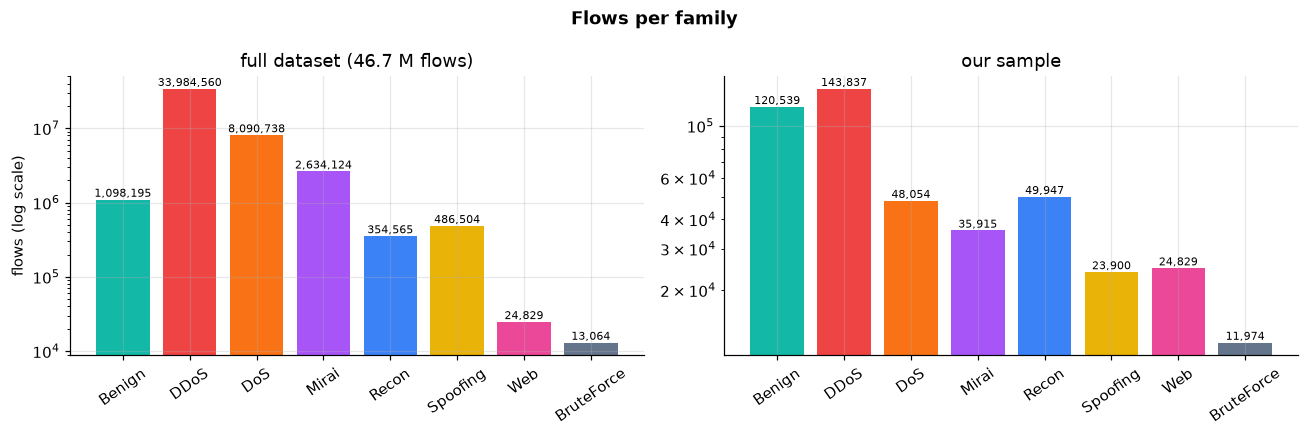

In [4]:
fam_full = overview.groupby("family")["flows in the full dataset"].sum().reindex(CATEGORIES)
fam_kept = df["family"].value_counts().reindex(CATEGORIES)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in [(axes[0], fam_full, "full dataset (46.7 M flows)"), (axes[1], fam_kept, "our sample")]:
    ax.bar(counts.index, counts.values, color=[FAMILY_C[c] for c in counts.index])
    ax.set_yscale("log")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=7.5)
axes[0].set_ylabel("flows (log scale)")
fig.suptitle("Flows per family", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "01_families.png", bbox_inches="tight")
plt.show()

how do the families differ? four of the most telling numbers, on a log scale. floods send packets very fast and
small, the web attacks and brute force look much more like normal browsing, which already hints at which attacks
will be hard to catch.

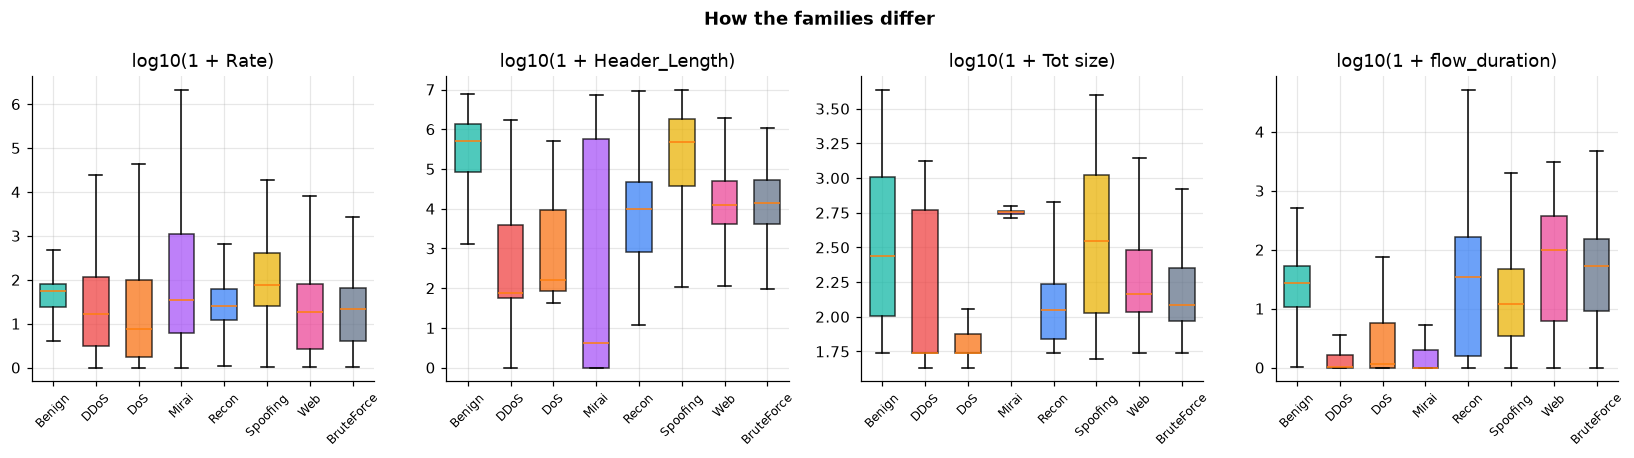

In [5]:
show = ["Rate", "Header_Length", "Tot size", "flow_duration"]
shuffled = df.sample(frac=1, random_state=SEED)
look = shuffled[shuffled.groupby("family").cumcount() < 3000]   # up to 3,000 random flows per family
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2))
for ax, col in zip(axes, show):
    data = [np.log10(1 + look.loc[look.family == f, col]) for f in CATEGORIES]
    box = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.6)
    for patch, fam in zip(box["boxes"], CATEGORIES):
        patch.set_facecolor(FAMILY_C[fam])
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(CATEGORIES) + 1), CATEGORIES, rotation=45, fontsize=8)
    ax.set_title(f"log10(1 + {col})")
fig.suptitle("How the families differ", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "02_feature_by_family.png", bbox_inches="tight")
plt.show()

many of the 46 columns say nearly the same thing (`Rate` and `Srate`, the packet-size summaries `Tot sum`, `AVG`,
`Tot size`, `Magnitue`). strongly linked columns dont hurt the tree models, but they make the logistic regression's
weights hard to read and they double-count evidence for naive bayes, which assumes every column is independent.

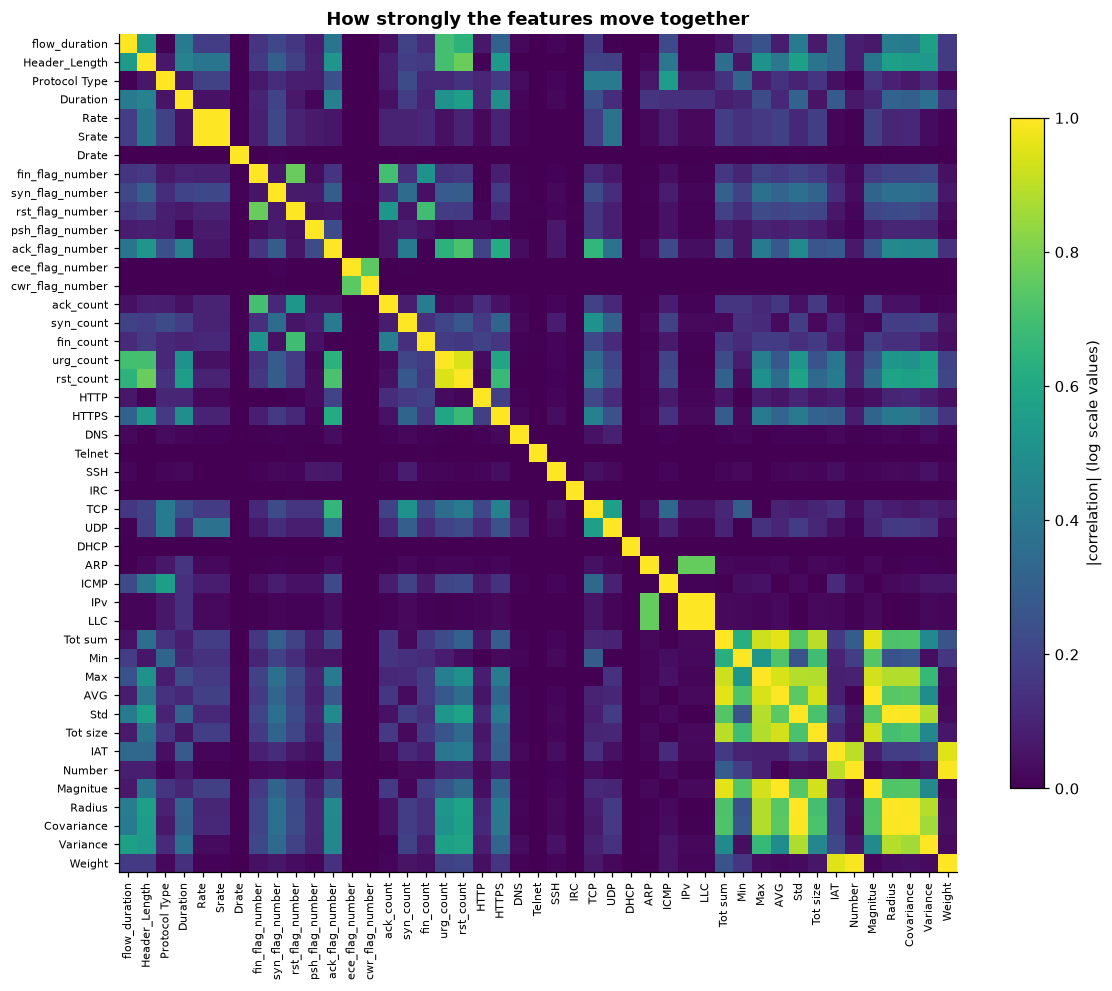

most linked pairs:
IPv      LLC           1.000
Rate     Srate         1.000
Std      Radius        0.999
AVG      Magnitue      0.999
Radius   Covariance    0.996
Std      Covariance    0.994
Number   Weight        0.990
Tot sum  AVG           0.958


In [6]:
corr = np.log1p(df[varying]).corr().abs()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(varying)), varying, rotation=90, fontsize=7)
ax.set_yticks(range(len(varying)), varying, fontsize=7)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="|correlation| (log scale values)")
ax.set_title("How strongly the features move together", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "03_correlation.png", bbox_inches="tight")
plt.show()
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack().sort_values(ascending=False)
print("most linked pairs:")
print(pairs.head(8).round(3).to_string())

and a 2-D map of all 46 numbers squeezed down with PCA (principal component analysis). the floods form tight
clusters of their own, while web, brute force and benign traffic sit on top of each other. a model will need more
than two directions to pull those apart.

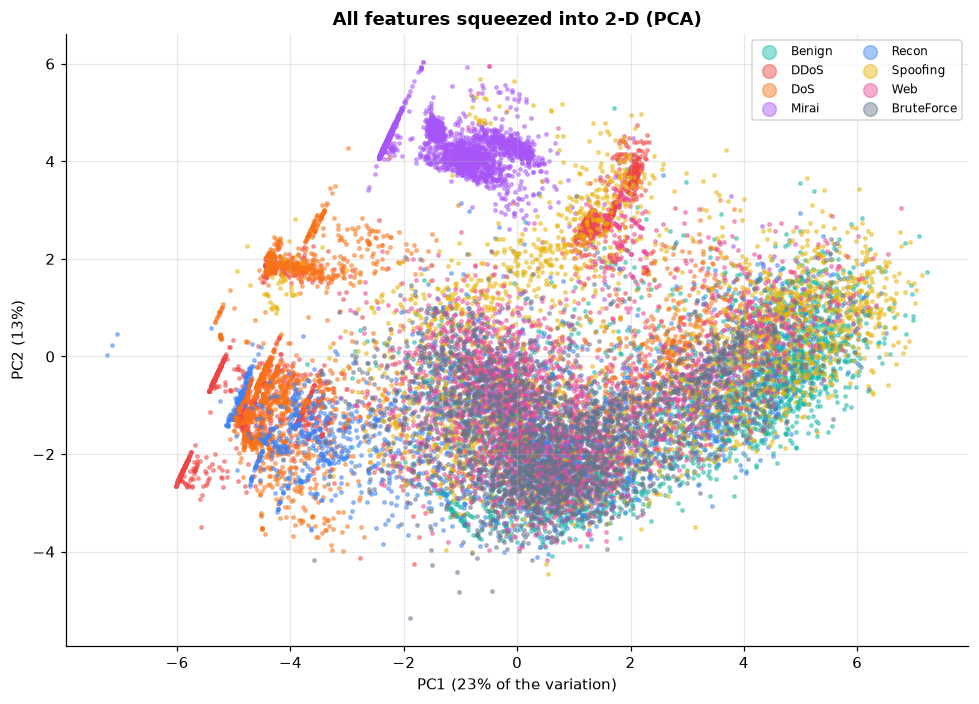

2 components keep 36% of the variation; 20 of the 45 features' worth of components are needed for 95%


In [7]:
pca_rows = shuffled[shuffled.groupby("family").cumcount() < 2500]
pca_x = np.log1p(pca_rows[FEATURES])
pca = PCA(n_components=2, random_state=SEED)
xy = pca.fit_transform((pca_x - pca_x.mean()) / pca_x.std().replace(0, 1))
fig, ax = plt.subplots(figsize=(9, 6.5))
for fam in CATEGORIES:
    m = (pca_rows.family == fam).to_numpy()
    ax.scatter(xy[m, 0], xy[m, 1], s=5, alpha=0.45, color=FAMILY_C[fam], label=fam)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of the variation)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
ax.legend(markerscale=4, fontsize=8, ncol=2)
ax.set_title("All features squeezed into 2-D (PCA)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "04_pca.png", bbox_inches="tight")
plt.show()
full_pca = PCA(random_state=SEED).fit((pca_x - pca_x.mean()) / pca_x.std().replace(0, 1))
kept = np.cumsum(full_pca.explained_variance_ratio_)
print(f"2 components keep {kept[1]:.0%} of the variation; {np.searchsorted(kept, 0.95) + 1} of the "
      f"{len(FEATURES)} features' worth of components are needed for 95%")

## 5. the IAT trap: one column that knows the answer

before training anything serious, a sanity check: how well does a plain decision tree do with **one column at a
time**? one column, `IAT`, is suspicious: its supposed to be the time between packets, but its values sit around
83 million and form neat bands per attack.

the test: a decision tree that must name all 34 labels (33 attacks + benign), given (a) `IAT` alone, (b) the 45 real
traffic columns without it, (c) everything. on a 60,000-flow slice, with its own train / test split.

In [8]:
probe = df.sample(min(len(df), 60_000), random_state=SEED)
p_train, p_test = train_test_split(probe, test_size=0.3, random_state=SEED, stratify=probe[LABEL])
trap = []
for name, cols in [("IAT alone (1 column)", LEAKY), (f"traffic features without IAT ({len(FEATURES)})", FEATURES),
                   (f"everything ({len(COLUMNS)})", COLUMNS)]:
    tree = DecisionTreeClassifier(min_samples_leaf=5, random_state=SEED).fit(p_train[cols], p_train[LABEL])
    guess = tree.predict(p_test[cols])
    trap.append({"features given": name, "accuracy, naming all 34 labels": accuracy_score(p_test[LABEL], guess),
                 "macro F1": f1_score(p_test[LABEL], guess, average="macro")})
trap = pd.DataFrame(trap).set_index("features given")
trap.style.format("{:.1%}")

,"accuracy, naming all 34 labels",macro F1
features given,,
IAT alone (1 column),87.7%,84.2%
traffic features without IAT (45),74.9%,63.6%
everything (46),90.2%,84.5%


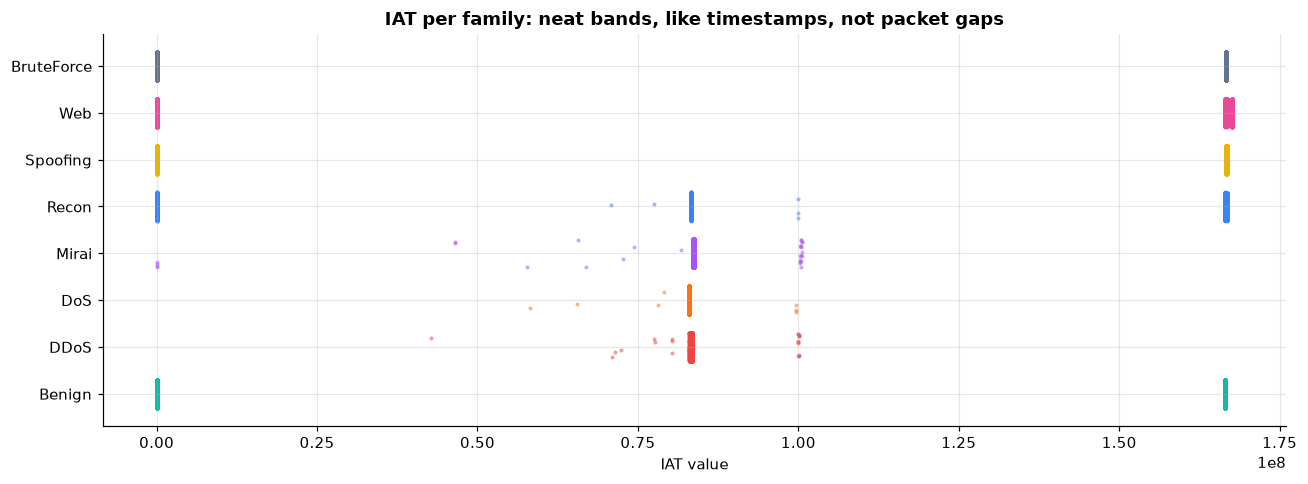

In [9]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for i, fam in enumerate(CATEGORIES):
    vals = look.loc[look.family == fam, "IAT"]
    ax.scatter(vals, np.full(len(vals), i) + np.random.default_rng(SEED).uniform(-0.3, 0.3, len(vals)), s=3,
               alpha=0.4, color=FAMILY_C[fam])
ax.set_yticks(range(len(CATEGORIES)), CATEGORIES)
ax.set_xlabel("IAT value")
ax.set_title("IAT per family: neat bands, like timestamps, not packet gaps", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "05_iat_trap.png", bbox_inches="tight")
plt.show()

**one column alone does better than all 45 real traffic features together.** that cant be real traffic knowledge.
CICIoT2023's feature extractor records `IAT` in a way that tracks *when* in the capture each flow happened, and the
researchers ran each attack in its own time window. so `IAT` mostly tells the model *which recording session* a
flow came from, and the session tells it the attack.

on a real network that clue doesnt exist: a new attack happens at a new time. a model that leans on `IAT` would look
brilliant in the notebook and fail on day one. this is a known problem in published CICIoT2023 results (many report
99%+), so **every model from here on uses the 45 traffic features without `IAT`**. the numbers get a bit lower and
a lot more honest.

## 6. the train / test split comes first

25% of the flows are locked away now, split so every one of the 34 labels has the same share in both halves (a
*stratified* split). nothing until the final scoring looks at them, and the cleaning steps (median fill, log, scaling)
are fitted on the training flows only, inside one sklearn `Pipeline` per model, so no test statistics leak in.

two targets come out of the same split: **normal (0) / intrusion (1)** for the main comparison, and the **family**
(8 classes) for the advanced version in section 11.

In [10]:
X = df[FEATURES]
(X_train, X_test, yb_train, yb_test, yf_train, yf_test,
 yl_train, yl_test) = train_test_split(X, df["intrusion"], df["family"], df[LABEL], test_size=0.25,
                                       random_state=SEED, stratify=df[LABEL])
print(f"train: {len(X_train):,} flows | test: {len(X_test):,} flows | {len(FEATURES)} features each")
print(f"intrusion share, train: {yb_train.mean():.1%} | test: {yb_test.mean():.1%}")
print(f"a model that always says 'intrusion' would score {yb_test.mean():.1%} accuracy and catch every attack, "
      "which is why accuracy alone is useless here")

train: 344,246 flows | test: 114,749 flows | 45 features each
intrusion share, train: 73.7% | test: 73.7%
a model that always says 'intrusion' would score 73.7% accuracy and catch every attack, which is why accuracy alone is useless here


## 7. every model from the syllabus, same data, same test

the case study names six algorithms. the course teaches a few more classifiers, so all of them run here, each inside
the same cleaning pipeline:

| syllabus module | model | how it decides, in one line | settings |
|---|---|---|---|
| V, classification | logistic regression | a weighted sum of the features, squashed into a probability | up to 2,000 steps |
| V, classification | KNN | the vote of the 5 most similar training flows | k = 5, on 50,000 training flows (it compares each test flow with every stored one, so all 300k would take hours) |
| V, classification | decision tree | a flowchart of yes/no questions on the features | leaves need at least 5 flows |
| VII, unsupervised | K-Means detector | learns clusters of **normal** traffic only, never sees an attack, and flags any flow far from every normal cluster | k from the elbow method below, alarm beyond the 99th percentile of normal distances |
| VIII, ensembles | random forest | 200 trees on reshuffled data, each split seeing a random subset of features, then a vote | 200 trees |
| VIII, ensembles | bagging | 100 full decision trees, each on a random half of the data, then a vote (every split sees every feature) | 100 trees |
| VIII, ensembles | AdaBoost | 200 one-question trees ("stumps"), each focusing on the flows the earlier ones got wrong | 200 stumps |
| VIII, ensembles | gradient boosting | trees added one by one, each fixing the remaining errors of the ones before | sklearn's histogram version, 300 rounds |
| IX, neural networks | perceptron | one artificial neuron: a weighted sum and a yes/no step | default |
| IX, neural networks | neural network (MLP) | two hidden layers of 64 and 32 neurons | stops when 10% held-out flows stop improving |
| case study (not in the syllabus) | naive bayes | probability of the features under each class, assuming they are independent | gaussian |

the K-Means detector is the odd one out: its the only model that never learns what an attack looks like, which
makes it the interesting one for unseen attacks (section 14). first, how many clusters? the **elbow method**: try
several k on normal training flows and look for where adding clusters stops helping much.

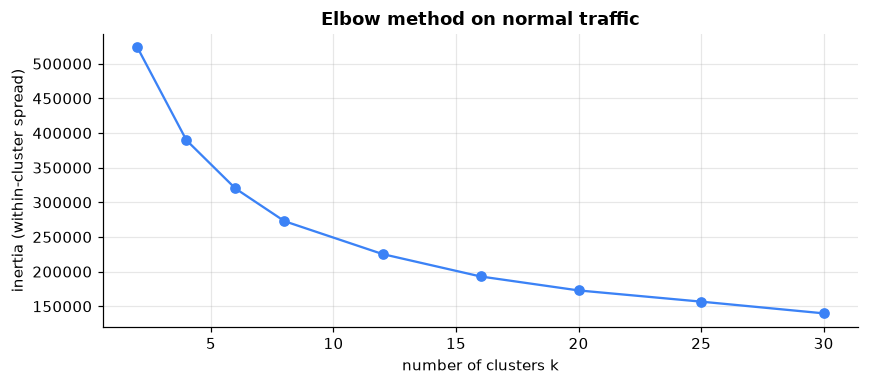

elbow at k = 20: past it, each extra cluster buys less than a tenth of what the first ones did


In [11]:
class KMeansDetector(BaseEstimator, ClassifierMixin):
    """Module VII as an intrusion detector: K-Means on normal flows only, alarm when a flow is far from every cluster."""

    def __init__(self, k=12, quantile=0.99, random_state=None):
        self.k, self.quantile, self.random_state = k, quantile, random_state

    def fit(self, X, y):
        normal = np.asarray(X)[np.asarray(y) == 0]          # the attack flows are never looked at
        self.kmeans_ = KMeans(self.k, n_init=3, random_state=self.random_state).fit(normal)
        self.cut_ = np.quantile(self.kmeans_.transform(normal).min(1), self.quantile)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        far = (self.kmeans_.transform(X).min(1) > self.cut_).astype(float)
        return np.column_stack([1 - far, far])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


prep = pipeline(None)[:-1].fit(X_train)                 # the same cleaning, to look at normal flows in model space
normal_x = prep.transform(X_train[yb_train == 0].sample(min(int((yb_train == 0).sum()), 30_000), random_state=SEED))
ks = [2, 4, 6, 8, 12, 16, 20, 25, 30]
inertia = [KMeans(k, n_init=3, random_state=SEED).fit(normal_x).inertia_ for k in ks]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(ks, inertia, marker="o", color="#3b82f6")
ax.set_xlabel("number of clusters k")
ax.set_ylabel("inertia (within-cluster spread)")
ax.set_title("Elbow method on normal traffic", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "06_kmeans_elbow.png", bbox_inches="tight")
plt.show()
drops = -np.diff(inertia) / np.diff(ks)                  # how much each extra cluster still buys
K = ks[1:][int(np.argmax(drops < 0.1 * drops[0]))] if (drops < 0.1 * drops[0]).any() else ks[-1]
print(f"elbow at k = {K}: past it, each extra cluster buys less than a tenth of what the first ones did")

now all 11, trained on the same training flows and scored on the same locked test flows. for each one: time to
train, time to score, and the saved model's size (the app has to load whichever one is deployed).

In [12]:
ALGORITHMS = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(min_samples_leaf=5, random_state=SEED),
    "K-Means detector": KMeansDetector(k=K, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    "Bagging": BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, max_samples=0.5, n_jobs=-1,
                                 random_state=SEED),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=SEED),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=300, random_state=SEED),
    "Perceptron": Perceptron(random_state=SEED),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=200,
                                          random_state=SEED),
    "Naive Bayes": GaussianNB(),
}
MODULE = {"Logistic Regression": "V", "KNN (k=5)": "V", "Decision Tree": "V", "K-Means detector": "VII",
          "Random Forest": "VIII", "Bagging": "VIII", "AdaBoost": "VIII", "Gradient Boosting": "VIII",
          "Perceptron": "IX", "Neural Network (MLP)": "IX", "Naive Bayes": "case study"}
KNN_ROWS = 5_000 if QUICK else 50_000
knn_rows = train_test_split(X_train.index, train_size=KNN_ROWS, random_state=SEED, stratify=yl_train)[0]

fitted, scores, rows = {}, {}, []
for name, algo in ALGORITHMS.items():
    rows_used = knn_rows if name.startswith("KNN") else X_train.index
    model = pipeline(clone(algo))
    t0 = time.time()
    model.fit(X_train.loc[rows_used], yb_train.loc[rows_used])
    t1 = time.time()
    # the perceptron only says yes / no, it has no probability, so its "probability" is 0 or 1
    proba = (model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba")
             else model.predict(X_test).astype(float))
    t2 = time.time()
    buf = io.BytesIO()
    joblib.dump(model, buf, compress=3)
    fitted[name], scores[name] = model, proba
    rows.append({"model": name, "module": MODULE[name], "train s": t1 - t0, "score s": t2 - t1,
                 "size MB": buf.tell() / 1e6, "trained on": len(rows_used)})
    print(f"{name:22s} trained in {t1 - t0:6.1f} s, scored {len(X_test):,} flows in {t2 - t1:5.1f} s")
cost = pd.DataFrame(rows).set_index("model")

Logistic Regression    trained in   16.5 s, scored 114,749 flows in   0.2 s


KNN (k=5)              trained in    0.4 s, scored 114,749 flows in  21.5 s


Decision Tree          trained in   15.2 s, scored 114,749 flows in   0.2 s


K-Means detector       trained in    4.9 s, scored 114,749 flows in   0.3 s


Random Forest          trained in   93.8 s, scored 114,749 flows in   2.1 s


...

AdaBoost               trained in  235.2 s, scored 114,749 flows in   2.7 s


Gradient Boosting      trained in   23.6 s, scored 114,749 flows in   1.3 s


Perceptron             trained in    3.9 s, scored 114,749 flows in   0.2 s


Neural Network (MLP)   trained in   79.3 s, scored 114,749 flows in   0.3 s


Naive Bayes            trained in    3.3 s, scored 114,749 flows in   0.3 s


## 8. the comparison

every model says *intrusion* when its probability is 50% or more. the columns:

- **precision**: of the flows it flagged, how many really were attacks
- **recall** (the catch rate): of the real attacks, how many it flagged. *the* number for an IDS
- **F1**: one score that balances the two
- **missed attacks** (false negatives): attacks that walked straight through. the expensive mistake
- **false alarms** (false positives): normal flows flagged, which wastes the security team's time

In [13]:
def binary_metrics(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {"accuracy": accuracy_score(y_true, pred), "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred), "F1": f1_score(y_true, pred), "missed attacks": int(fn),
            "false alarms": int(fp), "miss rate": fn / (fn + tp), "false alarm rate": fp / (fp + tn)}


board = pd.DataFrame({name: binary_metrics(yb_test, proba) for name, proba in scores.items()}).T
board = board.join(cost).sort_values(["recall", "F1"], ascending=False)
board.index.name = "model"
board.style.format({"accuracy": "{:.2%}", "precision": "{:.2%}", "recall": "{:.2%}", "F1": "{:.2%}",
                    "missed attacks": "{:,.0f}", "false alarms": "{:,.0f}", "miss rate": "{:.2%}",
                    "false alarm rate": "{:.2%}", "train s": "{:.1f}", "score s": "{:.1f}", "size MB": "{:.1f}",
                    "trained on": "{:,.0f}"})

,accuracy,precision,recall,F1,missed attacks,false alarms,miss rate,false alarm rate,module,train s,score s,size MB,trained on
model,,,,,,,,,,,,,
Bagging,94.81%,96.60%,96.35%,96.48%,"3,086","2,869",3.65%,9.52%,VIII,190.3,2.2,22.7,"344,246"
Random Forest,94.73%,96.50%,96.35%,96.43%,"3,088","2,954",3.65%,9.80%,VIII,93.8,2.1,106.5,"344,246"
Gradient Boosting,94.77%,96.93%,95.95%,96.44%,"3,430","2,568",4.05%,8.52%,VIII,23.6,1.3,0.5,"344,246"
Neural Network (MLP),94.51%,96.67%,95.85%,96.26%,"3,511","2,793",4.15%,9.27%,IX,79.3,0.3,0.1,"344,246"
Decision Tree,92.43%,94.83%,94.91%,94.87%,"4,308","4,377",5.09%,14.52%,V,15.2,0.2,0.3,"344,246"
KNN (k=5),92.27%,96.04%,93.37%,94.68%,"5,612","3,259",6.63%,10.81%,V,0.4,21.5,5.6,"50,000"
AdaBoost,90.93%,94.29%,93.36%,93.82%,"5,620","4,784",6.64%,15.88%,VIII,235.2,2.7,0.0,"344,246"
Logistic Regression,90.27%,95.07%,91.55%,93.28%,"7,148","4,016",8.45%,13.33%,V,16.5,0.2,0.0,"344,246"
Perceptron,87.62%,95.46%,87.37%,91.23%,"10,689","3,519",12.63%,11.68%,IX,3.9,0.2,0.0,"344,246"


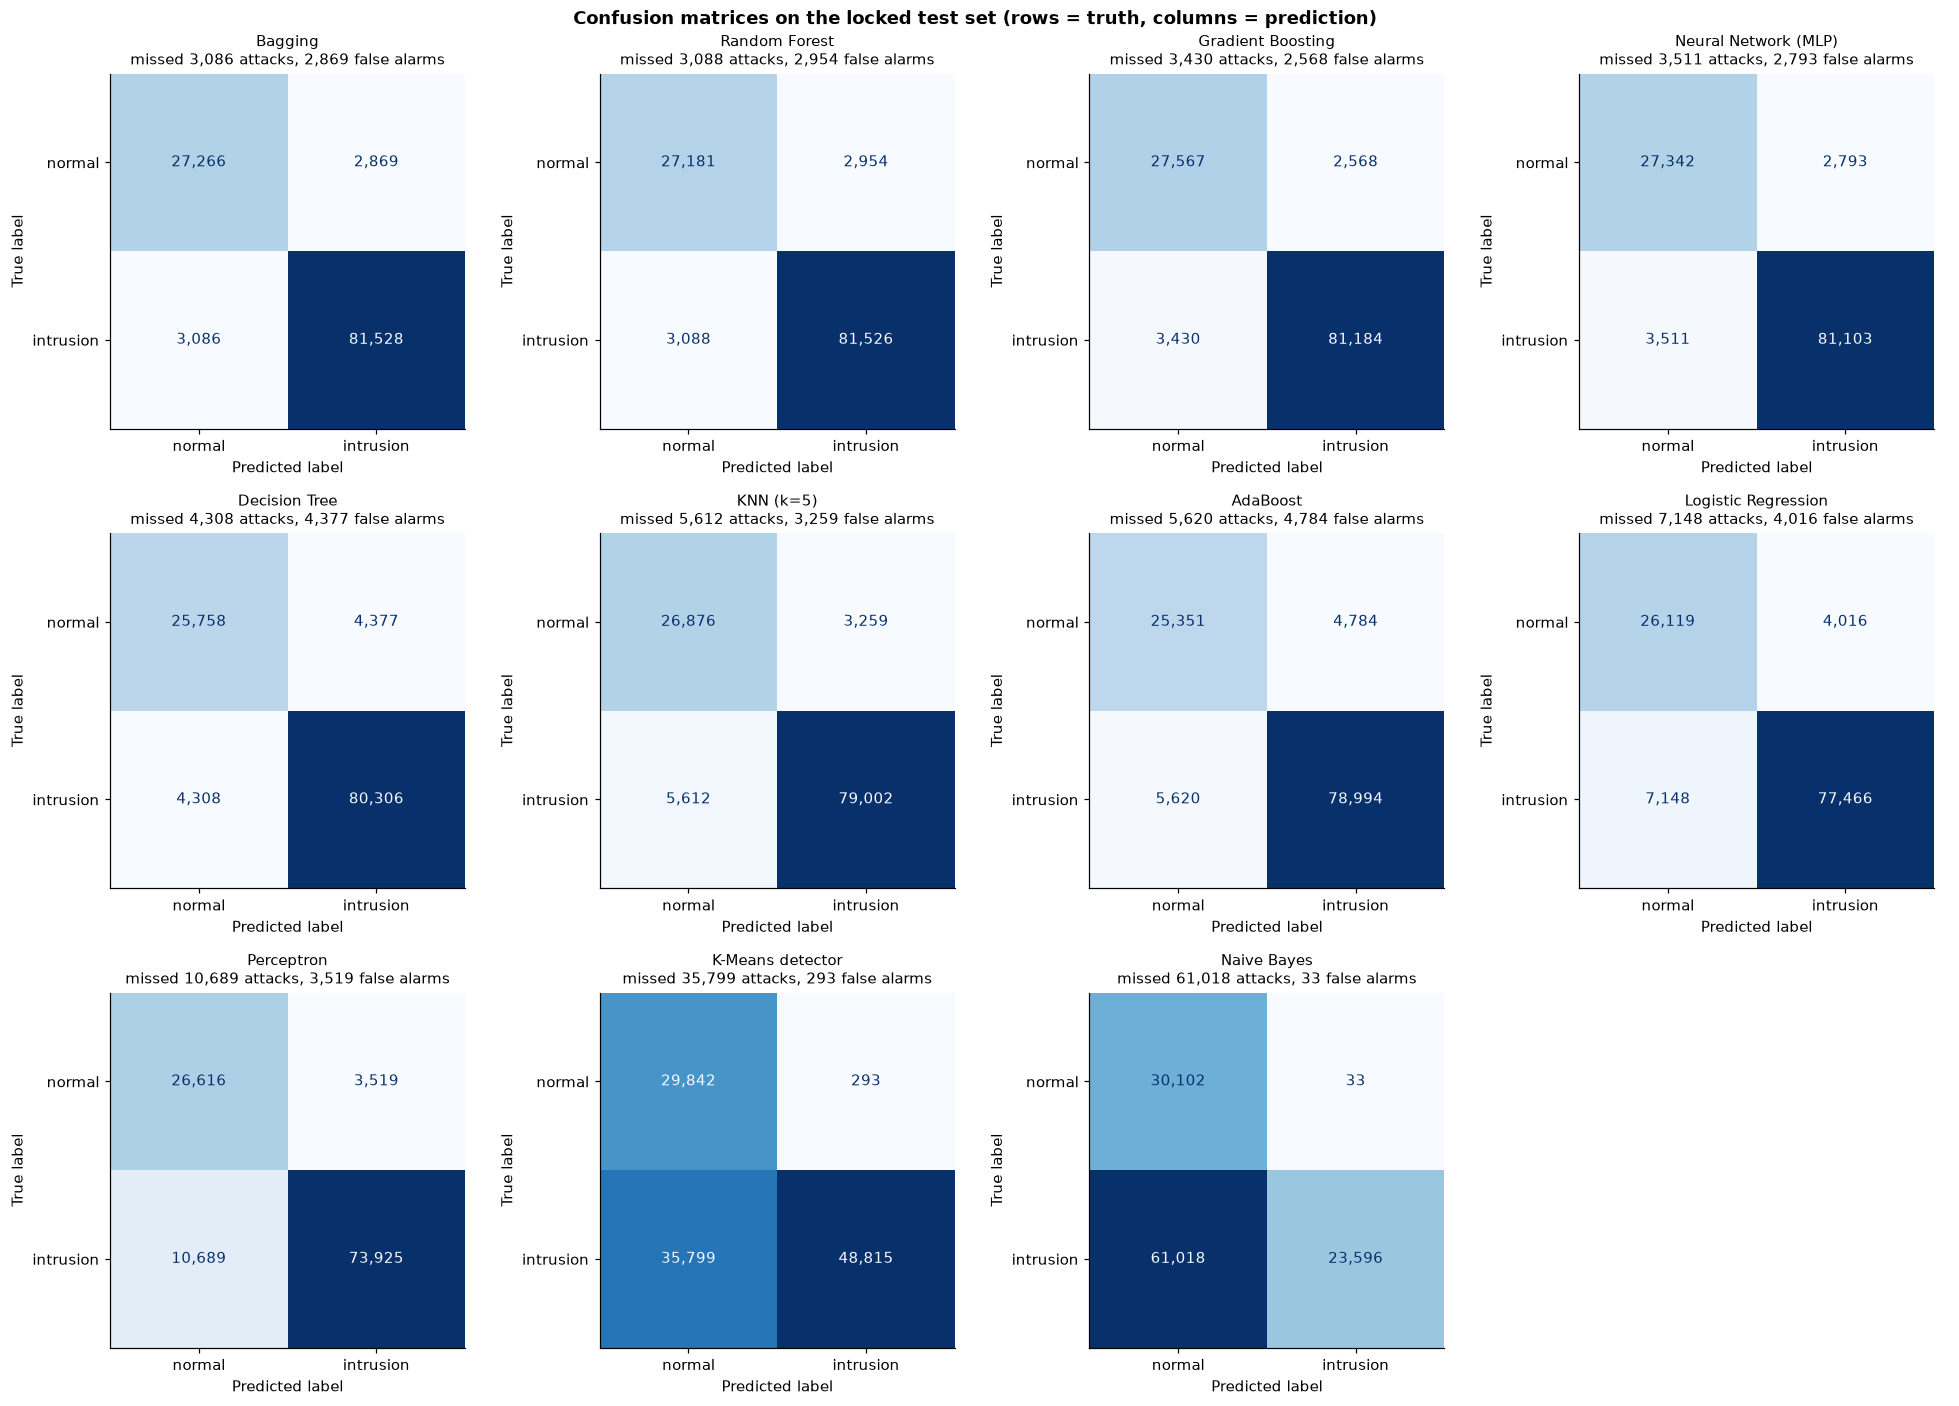

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
for ax in axes.ravel()[len(board):]:
    ax.axis("off")
for ax, name in zip(axes.ravel(), board.index):
    pred = (scores[name] >= 0.5).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(yb_test, pred), display_labels=["normal", "intrusion"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format=",")
    ax.set_title(f"{name}\nmissed {board.loc[name, 'missed attacks']:,.0f} attacks, "
                 f"{board.loc[name, 'false alarms']:,.0f} false alarms", fontsize=10)
    ax.grid(False)
fig.suptitle("Confusion matrices on the locked test set (rows = truth, columns = prediction)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "07_confusion_matrices.png", bbox_inches="tight")
plt.show()

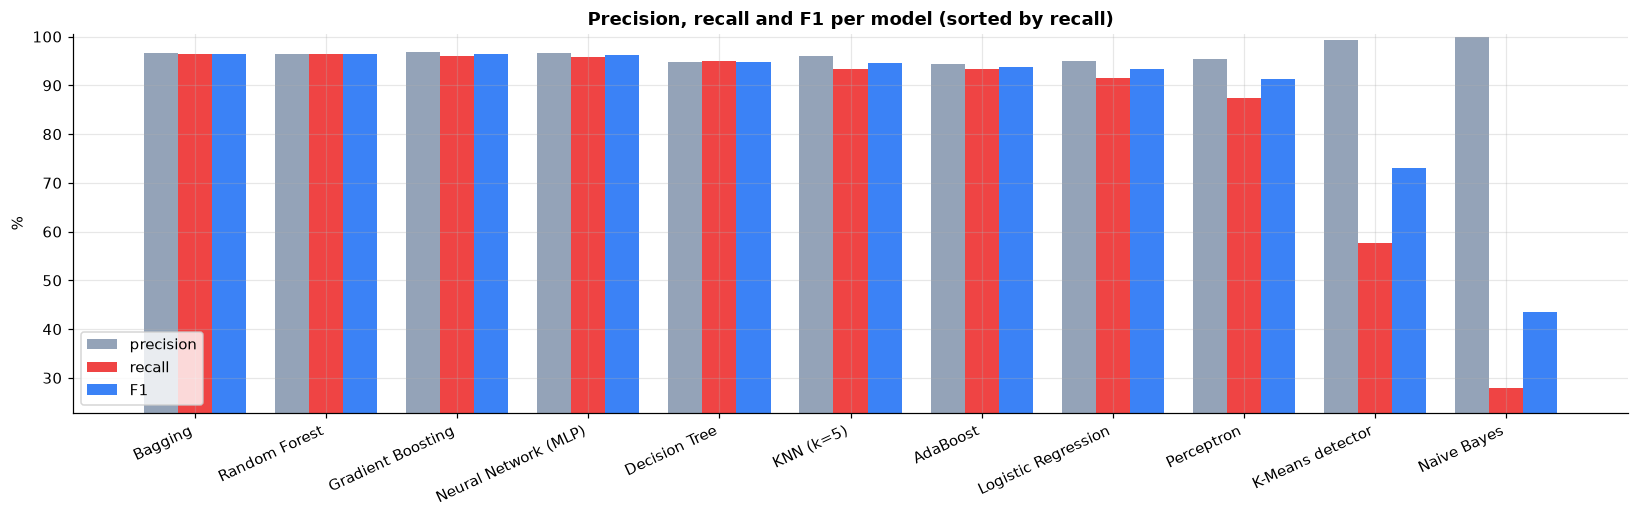

highest recall: Bagging, 96.35%, missing 3,086 of 84,614 attacks


In [15]:
fig, ax = plt.subplots(figsize=(15, 4.8))
metrics = ["precision", "recall", "F1"]
width = 0.26
for i, metric in enumerate(metrics):
    ax.bar(np.arange(len(board)) + (i - 1) * width, board[metric] * 100, width, label=metric,
           color=["#94a3b8", ATTACK_C, "#3b82f6"][i])
ax.set_xticks(range(len(board)), board.index, rotation=25, ha="right")
low = max(0, float(board[metrics].min().min() * 100) - 5)
ax.set_ylim(low, 100.5)
ax.set_ylabel("%")
ax.legend(loc="lower left")
ax.set_title("Precision, recall and F1 per model (sorted by recall)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "08_model_comparison.png", bbox_inches="tight")
plt.show()
best = board.index[0]
print(f"highest recall: {best}, {board.loc[best, 'recall']:.2%}, "
      f"missing {board.loc[best, 'missed attacks']:,.0f} of {int(yb_test.sum()):,} attacks")

## 9. the models' outputs side by side

the scores above are averages. here are the actual outputs. first, **which model catches which attack family**:
each cell is the share of that family's test flows the model flagged (for benign: the share it correctly let
through). a model can have a fine average and still be blind to one family.

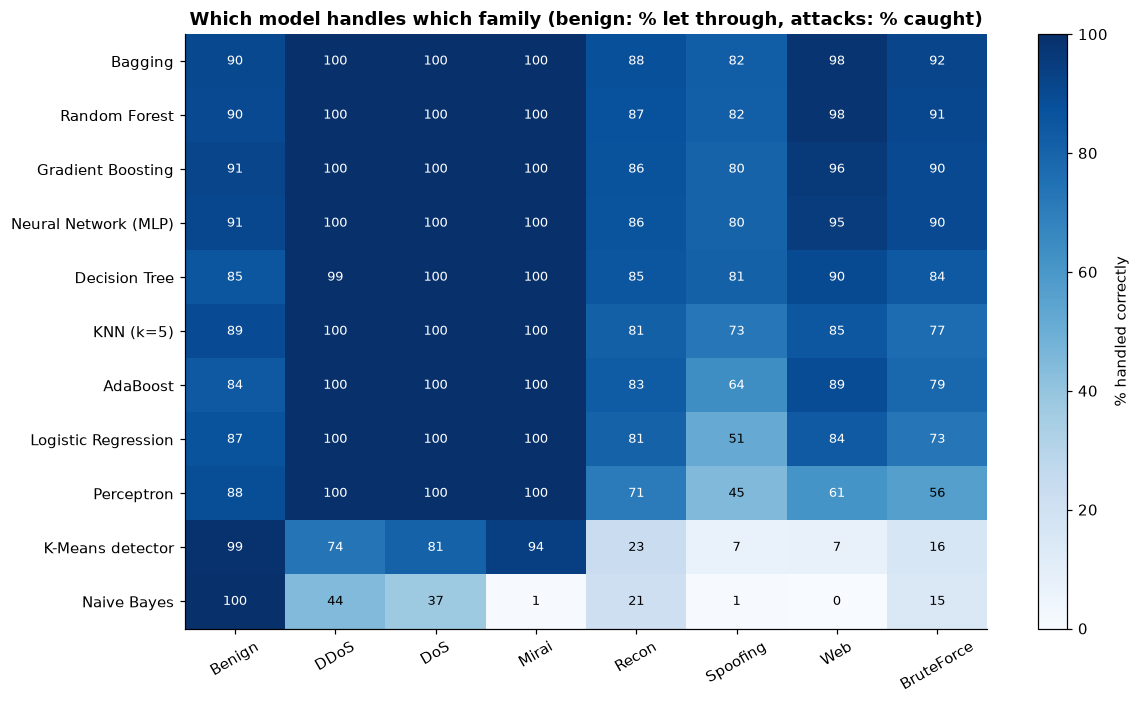

In [16]:
by_family = pd.DataFrame({name: [(((scores[name] >= 0.5).astype(int) == (fam != "Benign"))[(yf_test == fam).to_numpy()]).mean()
                                 for fam in CATEGORIES] for name in board.index}, index=CATEGORIES).T
fig, ax = plt.subplots(figsize=(11, 6.5))
im = ax.imshow(by_family * 100, cmap="Blues", vmin=0, vmax=100, aspect="auto")   # one hue: darker = better
ax.set_xticks(range(len(CATEGORIES)), CATEGORIES, rotation=30)
ax.set_yticks(range(len(board)), board.index)
for i in range(len(board)):
    for j in range(len(CATEGORIES)):
        v = by_family.iat[i, j] * 100
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8.5, color="white" if v > 60 else "black")
ax.grid(False)
fig.colorbar(im, ax=ax, label="% handled correctly")
ax.set_title("Which model handles which family (benign: % let through, attacks: % caught)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "09_recall_by_family_model.png", bbox_inches="tight")
plt.show()

and one real test flow from each family, with every model's verdict on it (🚨 = flagged as intrusion, with the
model's intrusion probability). where the models disagree is where the hard cases are.

In [17]:
rng = np.random.default_rng(SEED)
picks = [rng.choice(X_test.index[(yf_test == fam).to_numpy()]) for fam in CATEGORIES]
pos = X_test.index.get_indexer(picks)
outputs = pd.DataFrame({name: [f"{'🚨' if scores[name][i] >= 0.5 else '✅'} {scores[name][i]:.2f}" for i in pos]
                        for name in board.index}, index=[f"{yf_test[p]} · {yl_test[p]}" for p in picks]).T
outputs.columns.name = "true family · label"
outputs

true family · label,Benign · BenignTraffic,DDoS · DDoS-SynonymousIP_Flood,DoS · DoS-UDP_Flood,Mirai · Mirai-greeth_flood,Recon · VulnerabilityScan,Spoofing · MITM-ArpSpoofing,Web · SqlInjection,BruteForce · DictionaryBruteForce
Bagging,✅ 0.46,🚨 1.00,🚨 0.99,🚨 1.00,🚨 1.00,🚨 0.91,🚨 0.87,🚨 0.94
Random Forest,✅ 0.36,🚨 1.00,🚨 1.00,🚨 1.00,🚨 1.00,🚨 0.61,🚨 0.90,🚨 0.93
Gradient Boosting,✅ 0.21,🚨 1.00,🚨 1.00,🚨 1.00,🚨 1.00,🚨 0.67,🚨 0.89,🚨 1.00
Neural Network (MLP),✅ 0.17,🚨 1.00,🚨 1.00,🚨 1.00,🚨 1.00,✅ 0.41,🚨 0.97,🚨 1.00
Decision Tree,🚨 0.80,🚨 1.00,🚨 1.00,🚨 1.00,🚨 1.00,🚨 1.00,🚨 1.00,🚨 1.00
KNN (k=5),✅ 0.20,🚨 1.00,🚨 1.00,🚨 1.00,🚨 1.00,✅ 0.20,🚨 1.00,🚨 1.00
AdaBoost,🚨 0.51,🚨 0.74,🚨 0.68,🚨 0.69,🚨 0.61,🚨 0.54,🚨 0.54,🚨 0.55
Logistic Regression,🚨 0.83,🚨 1.00,🚨 1.00,🚨 1.00,🚨 1.00,✅ 0.48,🚨 0.79,🚨 1.00
Perceptron,🚨 1.00,🚨 1.00,🚨 1.00,🚨 1.00,🚨 1.00,✅ 0.00,✅ 0.00,🚨 1.00
K-Means detector,✅ 0.00,🚨 1.00,✅ 0.00,🚨 1.00,✅ 0.00,✅ 0.00,✅ 0.00,🚨 1.00


how often does each pair of models give the same verdict on the test flows? models that agree almost always (the
tree ensembles) make the same mistakes, so voting between them would add little.

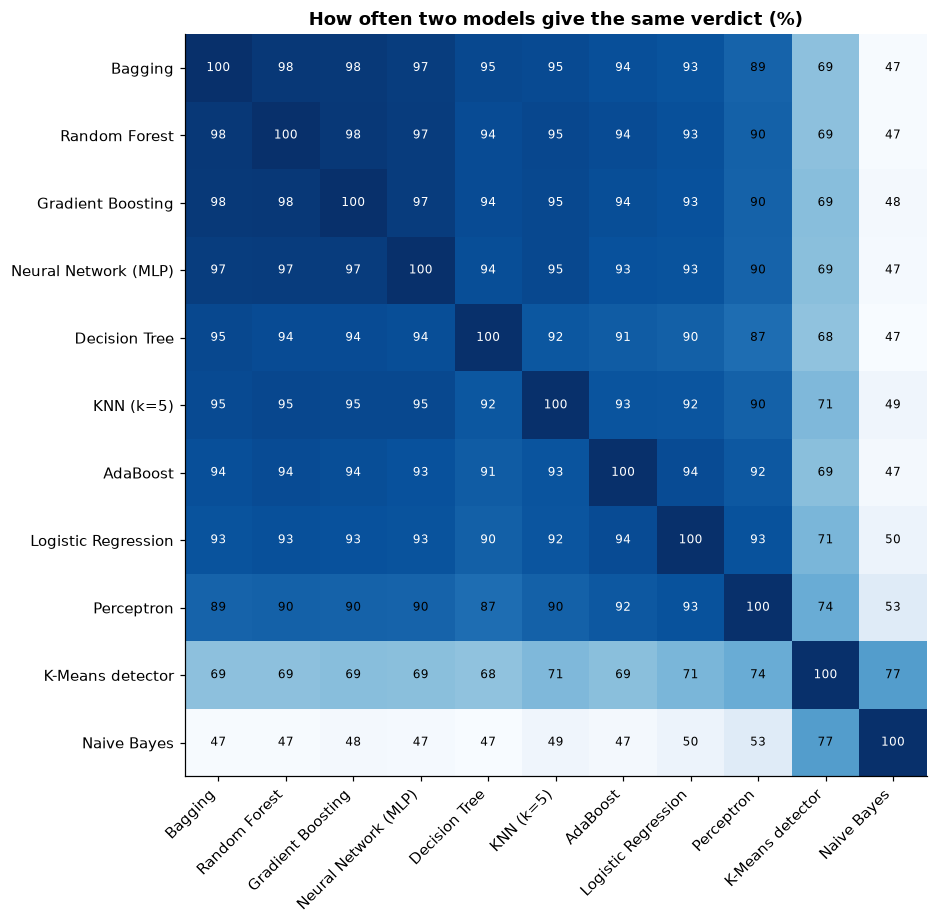

In [18]:
verdicts = pd.DataFrame({name: scores[name] >= 0.5 for name in board.index})
agree = pd.DataFrame([[(verdicts[a] == verdicts[b]).mean() for b in board.index] for a in board.index],
                     index=board.index, columns=board.index)
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(agree * 100, cmap="Blues", vmin=min(50, agree.values.min() * 100), vmax=100)
ax.set_xticks(range(len(board)), board.index, rotation=45, ha="right")
ax.set_yticks(range(len(board)), board.index)
for i in range(len(board)):
    for j in range(len(board)):
        ax.text(j, i, f"{agree.iat[i, j] * 100:.0f}", ha="center", va="center", fontsize=8,
                color="white" if agree.iat[i, j] > 0.9 else "black")
ax.grid(False)
ax.set_title("How often two models give the same verdict (%)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "10_model_agreement.png", bbox_inches="tight")
plt.show()

## 10. is that a lucky split? (5-fold cross-validation)

one test split could flatter a model by luck. 5-fold cross-validation re-trains the two strongest models five
times, each time scoring a different fifth of the training flows, and reports the spread.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
for name in ["Random Forest", "Gradient Boosting"]:
    res = cross_validate(pipeline(clone(ALGORITHMS[name])), X_train, yb_train, cv=cv,
                         scoring=["recall", "precision", "f1"], n_jobs=1)
    for fold in range(5):
        cv_rows.append({"model": name, "fold": fold + 1, "recall": res["test_recall"][fold],
                        "precision": res["test_precision"][fold], "F1": res["test_f1"][fold]})
cv_table = pd.DataFrame(cv_rows)
cv_summary = cv_table.groupby("model")[["recall", "precision", "F1"]].agg(["mean", "std"])
cv_summary.style.format("{:.3%}")

## 11. which features give an attack away?

two views. the random forest's built-in importance (how much each feature helped its splits), and **permutation
importance** on the test flows: shuffle one feature, so its link to the answer breaks, and measure how much the
gradient boosting model's F1 drops. a big drop means the model really relies on that feature.

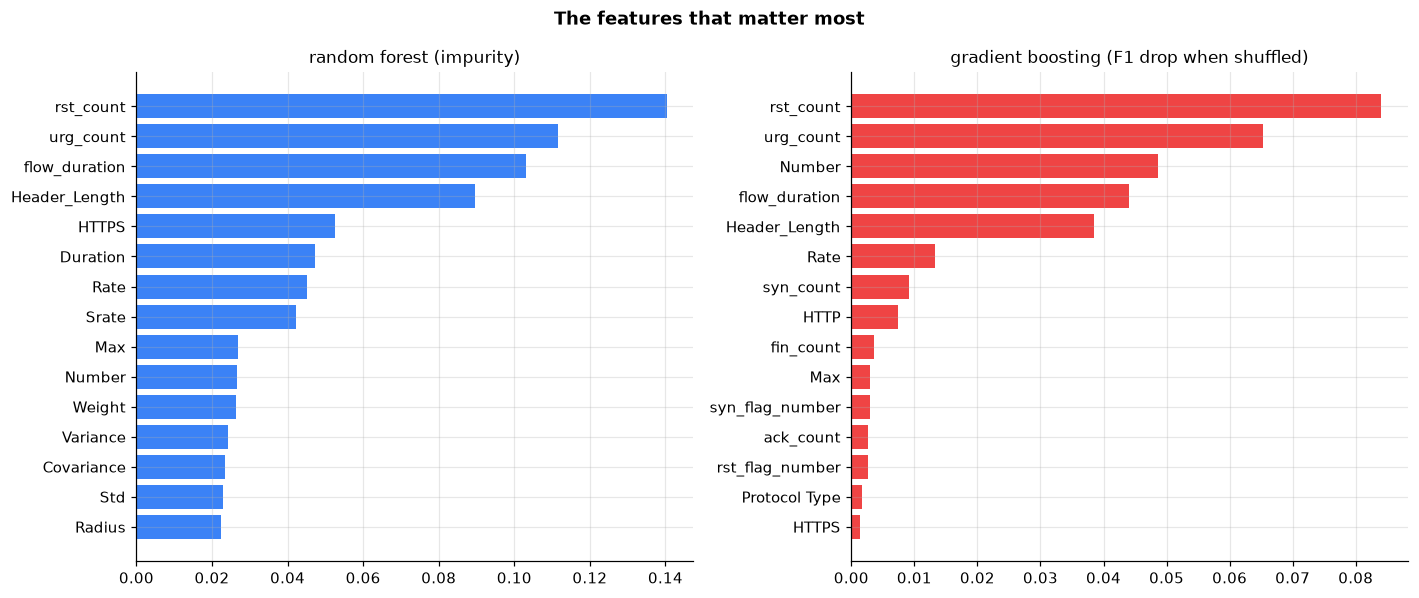

,random forest (impurity),gradient boosting (F1 drop when shuffled)
rst_count,0.1403,0.0841
urg_count,0.1115,0.0654
Number,0.0265,0.0487
flow_duration,0.1030,0.0440
Header_Length,0.0896,0.0385
Rate,0.0452,0.0133
syn_count,0.0189,0.0092
HTTP,0.0062,0.0074
fin_count,0.0113,0.0035
Max,0.0270,0.0029


In [20]:
imp_rows = X_test.sample(min(len(X_test), 20_000), random_state=SEED).index
perm = permutation_importance(fitted["Gradient Boosting"], X_test.loc[imp_rows], yb_test.loc[imp_rows],
                              scoring="f1", n_repeats=5, random_state=SEED, n_jobs=-1)
importance = pd.DataFrame({
    "random forest (impurity)": fitted["Random Forest"][-1].feature_importances_,
    "gradient boosting (F1 drop when shuffled)": perm.importances_mean}, index=FEATURES)
top = importance.sort_values("gradient boosting (F1 drop when shuffled)", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, col, color in zip(axes, importance.columns, ["#3b82f6", ATTACK_C]):
    s = importance[col].sort_values().tail(15)
    ax.barh(s.index, s.values, color=color)
    ax.set_title(col, fontsize=11)
fig.suptitle("The features that matter most", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "11_feature_importance.png", bbox_inches="tight")
plt.show()
top.head(10).style.format("{:.4f}")

## 12. the advanced version: which attack family is it?

the case study's advanced version names the attack category, not just *intrusion*. same split, same features, now
with 8 classes (benign + 7 families). gradient boosting again (section 13 explains the `balanced` setting).

In [21]:
family_model = pipeline(HistGradientBoostingClassifier(max_iter=300, class_weight="balanced", random_state=SEED))
family_model.fit(X_train, yf_train)
fam_pred = family_model.predict(X_test)
fam_report = pd.DataFrame({
    "precision": precision_score(yf_test, fam_pred, labels=CATEGORIES, average=None, zero_division=0),
    "recall": recall_score(yf_test, fam_pred, labels=CATEGORIES, average=None, zero_division=0),
    "F1": f1_score(yf_test, fam_pred, labels=CATEGORIES, average=None, zero_division=0),
    "test flows": yf_test.value_counts().reindex(CATEGORIES)}, index=CATEGORIES)
print(f"family accuracy {accuracy_score(yf_test, fam_pred):.2%} | macro F1 "
      f"{f1_score(yf_test, fam_pred, average='macro'):.2%}")
fam_report.sort_values("F1").style.format({"precision": "{:.1%}", "recall": "{:.1%}", "F1": "{:.1%}",
                                           "test flows": "{:,}"})

family accuracy 83.97% | macro F1 77.68%


,precision,recall,F1,test flows
BruteForce,44.5%,70.9%,54.7%,"2,994"
Spoofing,68.0%,65.8%,66.9%,"5,976"
Web,56.7%,83.0%,67.4%,"6,206"
Recon,83.9%,67.6%,74.9%,"12,486"
DoS,68.9%,89.4%,77.9%,"12,013"
Benign,92.3%,86.3%,89.2%,"30,135"
DDoS,95.9%,86.2%,90.8%,"35,960"
Mirai,99.9%,99.6%,99.7%,"8,979"


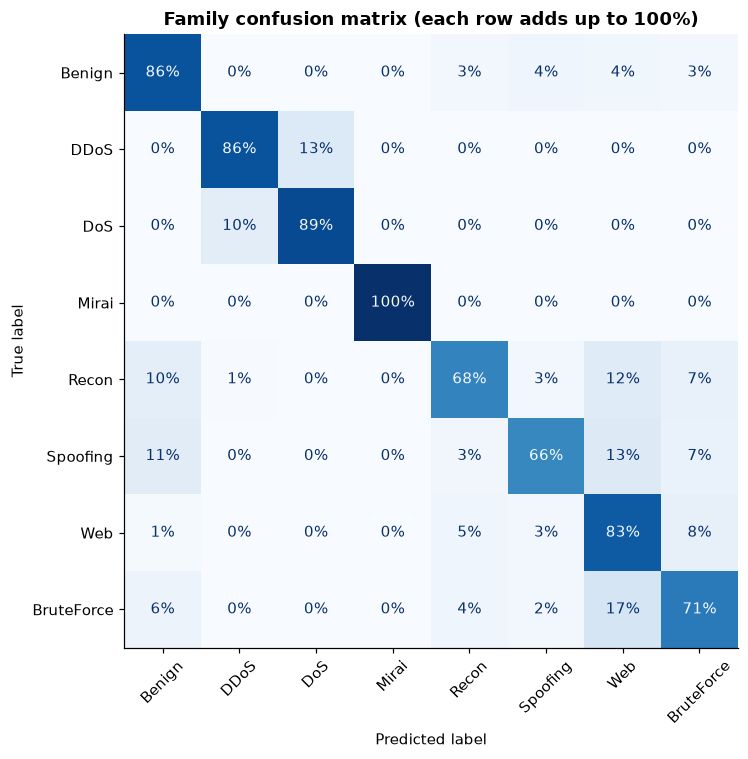

In [22]:
fig, ax = plt.subplots(figsize=(8.5, 7))
ConfusionMatrixDisplay.from_predictions(yf_test, fam_pred, labels=CATEGORIES, normalize="true", cmap="Blues",
                                        values_format=".0%", ax=ax, colorbar=False)
ax.set_title("Family confusion matrix (each row adds up to 100%)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.grid(False)
fig.tight_layout()
fig.savefig(FIG / "12_family_confusion.png", bbox_inches="tight")
plt.show()

and one level deeper: for each of the 33 attack types, how often the best binary model lets it **through as
normal**. this is where the false negatives live.

In [23]:
best_pred = pd.Series((scores[best] >= 0.5).astype(int), index=X_test.index)
per_type = pd.DataFrame({"family": yl_test.map(category), "label": yl_test, "missed": (best_pred == 0) & (yb_test == 1)})
per_type = per_type[yb_test == 1].groupby(["family", "label"]).agg(test_flows=("missed", "size"),
                                                                  missed=("missed", "sum"))
per_type["miss rate"] = per_type.missed / per_type.test_flows
hardest = per_type.sort_values("miss rate", ascending=False)
hardest.head(12).style.format({"test_flows": "{:,}", "missed": "{:,}", "miss rate": "{:.1%}"})

**hierarchical clustering** (module VII) shows why some types get confused: each of the 34 labels becomes one point
(its average flow, after the same cleaning), and Ward linkage joins the most alike first. labels that merge low on
the tree look alike to every model.

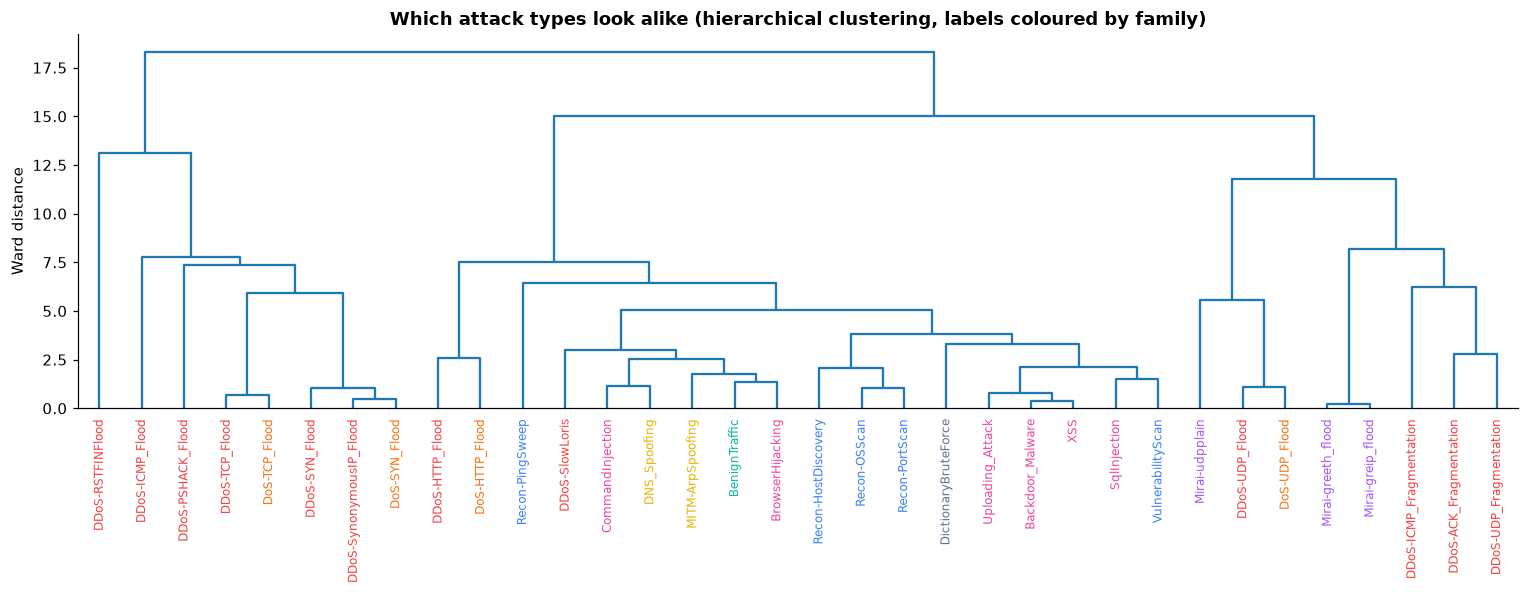

In [24]:
profiles = pd.DataFrame(prep.transform(X_train), index=X_train.index).groupby(yl_train).mean()
fig, ax = plt.subplots(figsize=(14, 5.5))
dendrogram(linkage(profiles, method="ward"), labels=profiles.index.tolist(), leaf_rotation=90, leaf_font_size=8,
           ax=ax, color_threshold=0)
for tick in ax.get_xticklabels():
    tick.set_color(FAMILY_C[category(tick.get_text())])
ax.set_ylabel("Ward distance")
ax.set_title("Which attack types look alike (hierarchical clustering, labels coloured by family)", fontweight="bold")
ax.grid(False)
fig.tight_layout()
fig.savefig(FIG / "13_attack_dendrogram.png", bbox_inches="tight")
plt.show()

## 13. what class imbalance does

three ways imbalance shows up here.

**a) accuracy lies.** section 6 already showed that always answering *intrusion* scores high accuracy while being
useless, which is why the comparison is sorted by recall and F1.

**b) rare families get ignored.** a model that minimises total mistakes can mostly ignore a family with a few
thousand rows. `class_weight="balanced"` makes each mistake on a rare family cost as much as many mistakes on a big
one. the same family model, trained both ways:

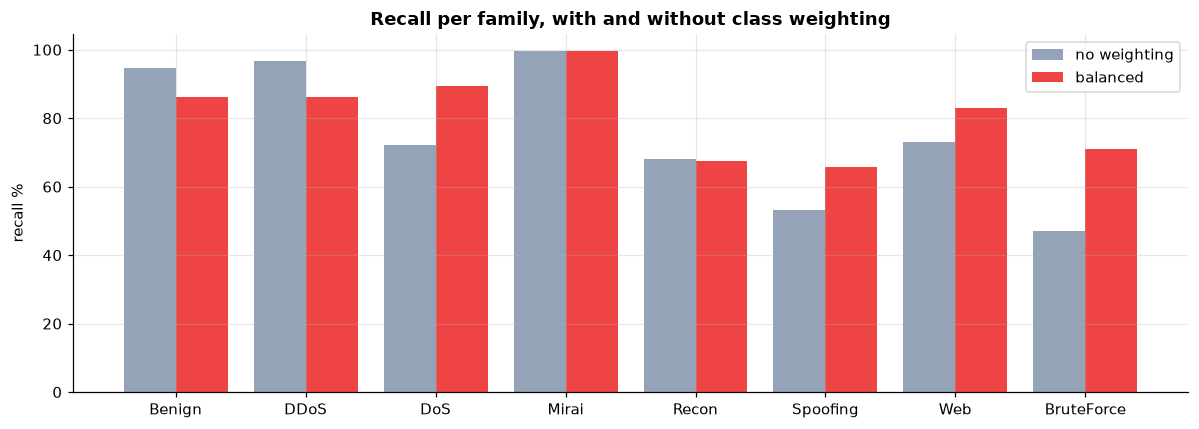

,"recall, no weighting","recall, balanced"
Benign,94.54%,86.31%
DDoS,96.63%,86.23%
DoS,72.28%,89.44%
Mirai,99.53%,99.57%
Recon,67.97%,67.61%
Spoofing,53.25%,65.81%
Web,73.04%,83.05%
BruteForce,47.03%,70.91%
macro F1,77.77%,77.68%
accuracy,85.81%,83.97%


In [25]:
plain_family = pipeline(HistGradientBoostingClassifier(max_iter=300, random_state=SEED)).fit(X_train, yf_train)
plain_pred = plain_family.predict(X_test)
imbalance = pd.DataFrame({
    "recall, no weighting": recall_score(yf_test, plain_pred, labels=CATEGORIES, average=None, zero_division=0),
    "recall, balanced": recall_score(yf_test, fam_pred, labels=CATEGORIES, average=None, zero_division=0)},
    index=CATEGORIES)
imbalance.loc["macro F1"] = [f1_score(yf_test, plain_pred, average="macro"), f1_score(yf_test, fam_pred, average="macro")]
imbalance.loc["accuracy"] = [accuracy_score(yf_test, plain_pred), accuracy_score(yf_test, fam_pred)]
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(CATEGORIES))
ax.bar(x - 0.2, imbalance.iloc[:len(CATEGORIES), 0] * 100, 0.4, label="no weighting", color="#94a3b8")
ax.bar(x + 0.2, imbalance.iloc[:len(CATEGORIES), 1] * 100, 0.4, label="balanced", color=ATTACK_C)
ax.set_xticks(x, CATEGORIES)
ax.set_ylabel("recall %")
ax.legend()
ax.set_title("Recall per family, with and without class weighting", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "14_class_weighting.png", bbox_inches="tight")
plt.show()
imbalance.style.format("{:.2%}")

balanced weights do **not** make the model better overall: macro F1 stays at about 78% and accuracy drops from
85.8% to 84.0%. what they do is **move** the recall: the rare families gain (brute force 47% → 71%, web 73% → 83%,
spoofing 53% → 66%, DoS 72% → 89%) and the big ones pay for it (DDoS 97% → 86%, benign 95% → 86%). for an IDS that
trade is the right one: a missed brute-force login costs far more than a DDoS flow labelled DoS, which is still
flagged as an attack. so the family model in the app uses balanced weights.

**c) precision depends on how rare attacks are.** our test set is mostly attacks, because the lab was. on a real
network attacks might be 1 flow in 1,000. the catch rate stays the same, but the same false-alarm rate now hits far
more normal flows, so precision drops. with the best model's recall and false-alarm rate:

In [26]:
r, f = board.loc[best, "recall"], board.loc[best, "false alarm rate"]
prevalence = pd.DataFrame({"attack share of traffic": [0.5, 0.1, 0.01, 0.001]})
prevalence["precision"] = r * prevalence["attack share of traffic"] / (
    r * prevalence["attack share of traffic"] + f * (1 - prevalence["attack share of traffic"]))
prevalence["false alarms per real attack caught"] = (1 - prevalence.precision) / prevalence.precision
prevalence.style.format({"attack share of traffic": "{:.1%}", "precision": "{:.1%}",
                         "false alarms per real attack caught": "{:.2f}"})

,attack share of traffic,precision,false alarms per real attack caught
0,50.0%,91.0%,0.10
1,10.0%,52.9%,0.89
2,1.0%,9.3%,9.78
3,0.1%,1.0%,98.71


## 14. can it catch an attack family it has never seen?

the real test of an IDS: new attacks show up all the time. so for each of the 7 families: train the gradient
boosting detector **with that whole family removed** from the training flows, then see how many of that family's
test flows it still flags as *intrusion*. if it does, it learned what "abnormal" looks like, not just a list of known
attacks. next to it, the K-Means detector from section 7, which never saw a single attack of any family.

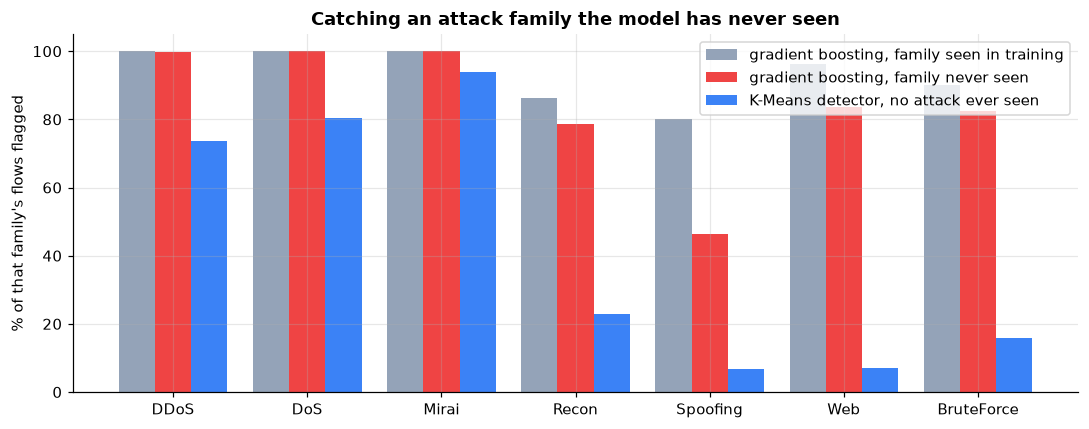

,caught when seen in training,caught when NEVER seen,false alarm rate on normal flows,K-Means detector (never saw ANY attack)
family left out of training,,,,
DDoS,100.0%,99.9%,8.4%,73.8%
DoS,100.0%,100.0%,8.5%,80.5%
Mirai,100.0%,100.0%,8.5%,94.0%
Recon,86.4%,78.5%,5.7%,22.9%
Spoofing,80.1%,46.5%,7.2%,6.8%
Web,96.2%,83.6%,6.5%,7.1%
BruteForce,90.0%,82.5%,7.6%,15.8%


In [27]:
gb_pred = pd.Series((scores["Gradient Boosting"] >= 0.5).astype(int), index=X_test.index)
unseen = []
for fam in CATEGORIES[1:]:
    keep = yf_train != fam
    model = pipeline(HistGradientBoostingClassifier(max_iter=300, random_state=SEED))
    model.fit(X_train[keep], yb_train[keep])
    fam_rows = yf_test == fam
    pred = model.predict(X_test)
    unseen.append({"family left out of training": fam,
                   "caught when seen in training": gb_pred[fam_rows].mean(),
                   "caught when NEVER seen": pred[fam_rows.to_numpy()].mean(),
                   "false alarm rate on normal flows": pred[(yb_test == 0).to_numpy()].mean(),
                   "K-Means detector (never saw ANY attack)": (scores["K-Means detector"][fam_rows.to_numpy()] >= 0.5).mean()})
unseen = pd.DataFrame(unseen).set_index("family left out of training")
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(unseen))
ax.bar(x - 0.27, unseen.iloc[:, 0] * 100, 0.27, label="gradient boosting, family seen in training", color="#94a3b8")
ax.bar(x, unseen.iloc[:, 1] * 100, 0.27, label="gradient boosting, family never seen", color=ATTACK_C)
ax.bar(x + 0.27, unseen.iloc[:, 3] * 100, 0.27, label="K-Means detector, no attack ever seen", color="#3b82f6")
ax.set_xticks(x, unseen.index)
ax.set_ylabel("% of that family's flows flagged")
ax.legend()
ax.set_title("Catching an attack family the model has never seen", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "15_unseen_families.png", bbox_inches="tight")
plt.show()
unseen.style.format("{:.1%}")

## 15. false positive and false negative patterns

**missed attacks:** which types slip through, and what the family model thinks they are. **false alarms:** what is
different about the normal flows the best model flags, compared with the normal flows it lets through (medians of
the most important features).

In [28]:
missed = (best_pred == 0) & (yb_test == 1)
print(f"{missed.sum():,} missed attacks. by family:")
print(yf_test[missed].value_counts().to_string())
false_alarm = (best_pred == 1) & (yb_test == 0)
fine_normal = (best_pred == 0) & (yb_test == 0)
print(f"\n{false_alarm.sum():,} false alarms out of {(yb_test == 0).sum():,} normal test flows")
top_feats = top.index[:8].tolist()
profile = pd.DataFrame({"normal flows flagged (false alarms)": X_test.loc[false_alarm, top_feats].median(),
                        "normal flows passed": X_test.loc[fine_normal, top_feats].median(),
                        "missed attacks": X_test.loc[missed, top_feats].median(),
                        "caught attacks": X_test.loc[(best_pred == 1) & (yb_test == 1), top_feats].median()})
profile.style.format("{:,.2f}")

3,086 missed attacks. by family:
family
Recon         1528
Spoofing      1058
BruteForce     253
Web            143
DDoS            99
DoS              3
Mirai            2

2,869 false alarms out of 30,135 normal test flows


,normal flows flagged (false alarms),normal flows passed,missed attacks,caught attacks
rst_count,27.00,746.00,308.05,0.11
urg_count,9.70,85.90,52.00,0.00
Number,5.50,5.50,9.50,9.50
flow_duration,30.55,26.56,15.07,0.25
Header_Length,"9,312.40","623,005.50","156,611.70",741.86
Rate,17.75,54.97,47.42,19.38
syn_count,0.60,0.60,0.50,0.01
HTTP,0.00,0.00,0.00,0.00


## 16. picking the alarm threshold

50% is just a default. lowering the threshold catches more attacks and raises more false alarms. the app has a
slider for it; here is what each setting does on the test flows, for the gradient boosting model the app uses.

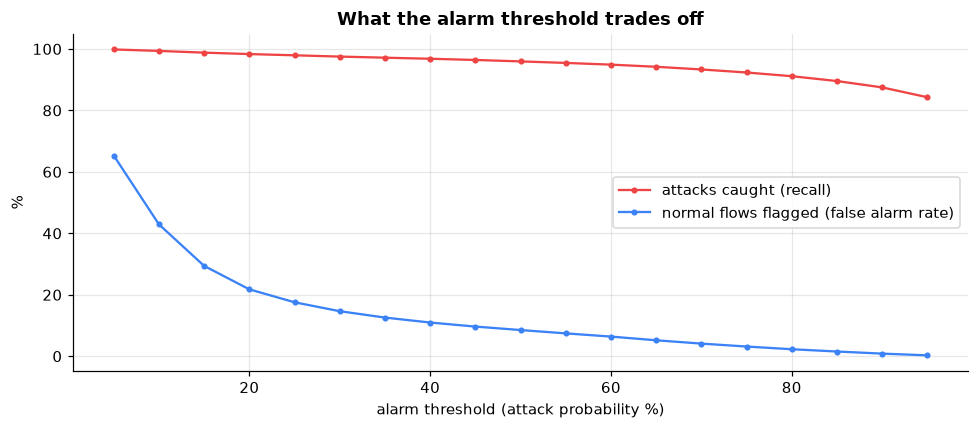

,recall,false alarm rate,missed attacks,false alarms
threshold,,,,
10,99.36%,42.90%,543,"12,929"
20,98.33%,21.77%,"1,411","6,560"
30,97.52%,14.66%,"2,101","4,417"
40,96.81%,10.97%,"2,701","3,306"
50,95.95%,8.52%,"3,430","2,568"
60,94.89%,6.40%,"4,321","1,928"
70,93.32%,4.11%,"5,650","1,239"
80,91.13%,2.28%,"7,504",686
90,87.49%,0.85%,"10,586",257


In [29]:
app_proba = scores["Gradient Boosting"]
sweep = pd.DataFrame([{"threshold": t, **binary_metrics(yb_test, app_proba, t / 100)} for t in range(5, 100, 5)])
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sweep.threshold, sweep.recall * 100, color=ATTACK_C, marker="o", ms=3, label="attacks caught (recall)")
ax.plot(sweep.threshold, sweep["false alarm rate"] * 100, color="#3b82f6", marker="o", ms=3,
        label="normal flows flagged (false alarm rate)")
ax.set_xlabel("alarm threshold (attack probability %)")
ax.set_ylabel("%")
ax.legend()
ax.set_title("What the alarm threshold trades off", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "16_threshold.png", bbox_inches="tight")
plt.show()
sweep.set_index("threshold")[["recall", "false alarm rate", "missed attacks", "false alarms"]].iloc[1::2].style.format(
    {"recall": "{:.2%}", "false alarm rate": "{:.2%}", "missed attacks": "{:,}", "false alarms": "{:,}"})

## 17. saving the model for the app

the app gets **gradient boosting** for both jobs: the normal / intrusion detector and the family model. the reason
is in the comparison table: its recall is right at the top, and its saved model is far smaller than the forest's or
bagging's, small enough to send to a browser. everything the app shows (test numbers, the threshold table, the
comparison, example flows from the test set) goes into one file, which is loaded back and checked against the
models in memory. `web/scripts/export_model.py` then turns it into the web app's JSON.

In [30]:
fam_proba = family_model.predict_proba(X_test)
examples = {}
for fam in CATEGORIES:
    rows_ = X_test.index[(yf_test == fam).to_numpy() & (fam_pred == fam) & ((app_proba >= 0.5) == (fam != "Benign"))]
    if len(rows_):
        pick = rows_[0]
        examples[f"{fam} · {yl_test[pick]}"] = X_test.loc[pick].to_dict()
miss_rows = X_test.index[missed.to_numpy() & ((app_proba < 0.5))]
if len(miss_rows):
    examples[f"missed · {yl_test[miss_rows[0]]} (gets through)"] = X_test.loc[miss_rows[0]].to_dict()

demo = X_test.sample(min(len(X_test), 300), random_state=SEED).assign(true_label=yl_test)
Path("data").mkdir(exist_ok=True)
demo.to_csv("data/demo_flows.csv", index=False)

bundle = {
    "binary": fitted["Gradient Boosting"], "family": family_model, "features": FEATURES, "families": CATEGORIES,
    "top_features": top.index[:8].tolist(), "examples": examples,
    "thresholds": sweep[["threshold", "recall", "false alarm rate"]].to_dict("records"),
    "comparison": board[["module", "accuracy", "precision", "recall", "F1", "missed attacks", "false alarms",
                         "size MB"]].reset_index().to_dict("records"),
    "family_report": fam_report.reset_index(names="family").to_dict("records"),
    "unseen": unseen.reset_index().to_dict("records"),
    "test": binary_metrics(yb_test, app_proba), "n_train": len(X_train), "n_test": len(X_test),
    "dataset": "CICIoT2023 (Canadian Institute for Cybersecurity, 2023)",
}
joblib.dump(bundle, MODELS / "ids_bundle.joblib", compress=3)
back = joblib.load(MODELS / "ids_bundle.joblib")
assert np.allclose(back["binary"].predict_proba(X_test)[:, 1], app_proba)
assert (back["family"].predict(X_test) == fam_pred).all()
print(f"saved models/ids_bundle.joblib ({(MODELS / 'ids_bundle.joblib').stat().st_size / 1e6:.1f} MB), "
      "loaded back, same predictions")
print("examples for the app:", list(examples))

results = {
    "flows_full": int(full_counts.sum()), "flows_sample": len(raw), "flows_clean": len(df),
    "duplicates_dropped": int(exact), "conflicts_dropped": int(conflict.sum()),
    "n_train": len(X_train), "n_test": len(X_test), "features": len(FEATURES),
    "iat_trap": trap.to_dict("index"), "comparison": board.reset_index().to_dict("records"), "best_recall_model": best,
    "cv": cv_table.groupby("model")[["recall", "precision", "F1"]].agg(["mean", "std"]).round(5).pipe(
        lambda t: t.set_axis([" ".join(c) for c in t.columns], axis=1)).to_dict("index"),
    "top_features": top.head(10).round(5).to_dict("index"), "family_report": fam_report.round(5).to_dict("index"),
    "family_accuracy": accuracy_score(yf_test, fam_pred), "family_macro_f1": f1_score(yf_test, fam_pred, average="macro"),
    "imbalance": imbalance.round(5).to_dict(), "hardest_types": hardest.head(12).reset_index().to_dict("records"),
    "unseen": unseen.round(5).reset_index().to_dict("records"), "app_model_test": binary_metrics(yb_test, app_proba),
    "kmeans_k": K, "by_family": by_family.round(5).to_dict("index"), "pca_95": int(np.searchsorted(kept, 0.95) + 1),
}
(REPORTS / "results.json").write_text(json.dumps(results, indent=1, default=float))
print("saved reports/results.json")

saved models/ids_bundle.joblib (4.7 MB), loaded back, same predictions
examples for the app: ['Benign · BenignTraffic', 'DDoS · DDoS-PSHACK_Flood', 'DoS · DoS-UDP_Flood', 'Mirai · Mirai-udpplain', 'Recon · Recon-HostDiscovery', 'Spoofing · DNS_Spoofing', 'Web · Uploading_Attack', 'BruteForce · DictionaryBruteForce', 'missed · DNS_Spoofing (gets through)']


saved reports/results.json


## 18. the deployed app: Flow Sentinel

**live: [walrus-flow-sentinel.pages.dev](https://walrus-flow-sentinel.pages.dev/)**, a Next.js web app (`web/`: Next.js 16, React 19, Tailwind, shadcn/ui, Recharts) in the Walrus Securitas look, hosted as a static site on Cloudflare Pages. there is no Python server: the
gradient boosting models saved above are exported by `web/scripts/export_model.py` as plain lists of trees (7 MB
of JSON, about 2 MB once a web host compresses it), and `web/src/lib/ids.ts` runs the same maths in the browser (clean, median fill, log, standardise,
walk the trees, sigmoid / softmax). the export first redoes the maths in numpy and checks it against sklearn, and
the web tests (`bun test`) check the browser version against sklearn's own probabilities on 300 test flows (largest
gap below 1e-9). so the site is a static build any host can serve, and nothing a user types leaves their browser.

four pages:

- **detector**: a strip of the 300 demo test flows (colour = true family, height = the model's intrusion score);
  click one, pick an example, or type in the features. it shows the verdict, the intrusion score against an alarm
  threshold slider (with what that threshold did on the test flows), and all 8 family probabilities
- **scan a file**: a CSV of up to 20,000 flows, scored in the browser, with a sortable, filterable table and a
  download. missing columns, unreadable files and bad cells (text, blanks, negative, infinite) are caught
- **model comparison**: all 11 models, the per-family heatmap, the never-seen-family test, cross-validation
- **data and method**: the pipeline, the IAT trap, the six answers below, the limitations

![detector, an attack](screenshots/app/01-detector-attack.png)

![detector, normal traffic](screenshots/app/02-detector-normal.png)

![detector, an attack the model misses](screenshots/app/03-detector-missed-attack.png)

![scanning the demo file](screenshots/app/04-scan-demo-file.png)

![input check: a CSV with missing columns](screenshots/app/05-scan-missing-columns.png)

![model comparison](screenshots/app/06-model-comparison.png)

## 19. answers and limitations

**1. can ML distinguish normal and malicious traffic?** yes. on 114,749 flows it never saw, the deployed gradient
boosting model catches **95.95%** of attacks with **96.9% precision**; the best models (bagging and random forest)
catch 96.35%. the floods (DDoS, DoS, Mirai) are caught almost 100% of the time by every model except naive bayes and
K-Means.

**2. which features contribute most?** `rst_count`, `urg_count`, `Number`, `flow_duration` and `Header_Length`
(permutation importance, section 11): the TCP flag counts and the size and length of the traffic window. floods and
scans leave their mark in exactly those.

**3. which algorithm has the highest recall?** bagging and random forest, tied at **96.35%** (3,086 and 3,088
attacks missed), confirmed by 5-fold cross-validation (random forest 96.17% ± 0.08). gradient boosting is 0.4 points
behind with fewer false alarms and a 0.5 MB model instead of 106 MB, so it is the one deployed.

**4. which attack categories are difficult?** reconnaissance and spoofing. the attack types missed most often are
`Recon-OSScan` (33% missed), `DNS_Spoofing` (21%), `Recon-PingSweep` (17%) and `MITM-ArpSpoofing` (15%): they send
a few ordinary-looking packets, not a flood. for naming the family, brute force (F1 55%), web (67%) and spoofing
(67%) are the hardest, and DoS and DDoS get mixed up with each other (they are the same attacks from one or many
machines).

**5. how does class imbalance affect the model?** three ways (section 13). accuracy misleads: always answering
"intrusion" scores 73.7%, and naive bayes reaches 99.9% precision by catching only 28% of attacks. rare families get
sacrificed unless weighted, and weighting trades big-family recall for rare-family recall rather than improving
everything. and precision depends on how rare attacks are: with an 8.5% false-alarm rate, if only 1% of real
traffic were attacks, about 9 in 10 alarms would be false.

**6. can it detect previously unseen traffic patterns?** partly (section 14). trained without a family, the model
still catches 100% of unseen DoS and Mirai and 99.9% of DDoS (they look like the other floods), 84% of web attacks,
83% of brute force and 79% of recon, but only **46% of spoofing**. the K-Means detector, which never saw any attack,
catches 94% of Mirai and 74-81% of the DoS/DDoS floods but under 25% of the quiet families. new loud attacks get
caught; new quiet ones mostly do not.

**limitations**

- **false alarms**: 8.5% of normal flows get flagged at the 50% threshold. raising the threshold to 90% cuts that to
  0.85% but the catch rate drops to 87.5% (the slider in the app). a real deployment would tune this per network
- **one lab, one network**: all traffic is from one IoT testbed, so another network needs re-testing
- **summaries, not packets**: each row averages a window of packets; the detector never sees single packets
- **sampling sets the mix**: the benign share was chosen by our sampling, not by a real network
- **the IAT leak** shows how easily a dataset can flatter a model; other columns could carry subtler leaks
- **one layer of defence**, not a guarantee